GREGORY BEWON FORWARD DIFFERENCE INTERPLOTING POLYNOMIAL

Interpolating Polynomial: 4.79999999998712*x**5 - 51.133333333197*x**4 + 217.813333332756*x**3 - 463.868166665446*x**2 + 494.481036665376*x - 210.769589999455
Value at x = 2.07: 0.727536159360170


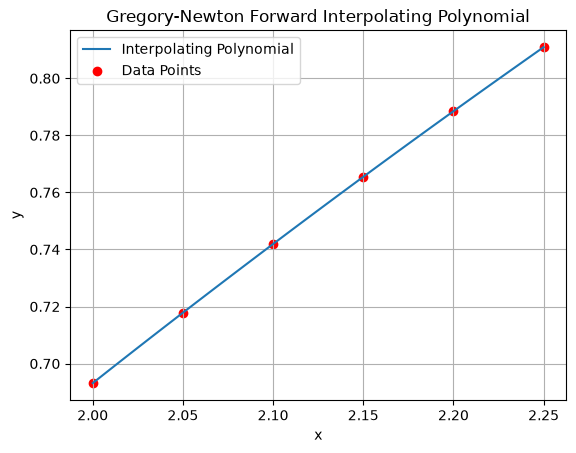

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


def forward_difference_table(y_values):
    n = len(y_values)
    table = np.zeros((n, n))
    table[:, 0] = y_values

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = table[i + 1][j - 1] - table[i][j - 1]

    return table


def gregory_newton_forward(x_values, y_values):
    n = len(x_values)
    h = x_values[1] - x_values[0]  # Assuming equal spacing

    x = sp.Symbol('x')
    u = (x - x_values[0]) / h

    table = forward_difference_table(y_values)

    polynomial = table[0, 0]

    fact = 1
    term = 1

    for i in range(1, n):
        fact *= i
        term *= (u - (i - 1))
        polynomial += (table[0, i] / fact) * term

    polynomial = sp.simplify(polynomial)

    return polynomial


# Example with equal spacing

#x_values = np.array([0, 1, 2, 3, 4])
#y_values = np.array([1, 2, 0, 5, 3])

x_values = np.array([2, 2.05, 2.10, 2.15, 2.20, 2.25])
y_values = np.array([0.69315, 0.71784, 0.74192, 0.76547, 0.78846, 0.81093])

#x_values = np.array([-2, -1, 0, 1, 3, 4])
#y_values = np.array([9, 16, 17, 18, 44, 81])


polynomial = gregory_newton_forward(x_values, y_values)

print("Interpolating Polynomial:", polynomial)


# Evaluate at x = ----

x_val = 2.07

y_at_x_val = polynomial.subs(sp.Symbol('x'), x_val)

print(f"Value at x = {x_val}: {y_at_x_val}")


# Plot the polynomial

x_range = np.linspace(min(x_values), max(x_values), 100)

y_range = [
    polynomial.subs(sp.Symbol('x'), x)
    for x in x_range
]

plt.plot(x_range, y_range, label='Interpolating Polynomial')

plt.scatter(
    x_values,
    y_values,
    color='red',
    label='Data Points'
)

plt.xlabel('x')
plt.ylabel('y')

plt.title('Gregory-Newton Forward Interpolating Polynomial')

plt.legend()
plt.grid()

plt.show()